# Module 11 — Logistic Regression & Generalised Linear Models

**Statistics Deep Dive · Notebook 11 of 13**

Linear regression models a numeric outcome. But many outcomes are not numeric: *churned or stayed*, *defaulted or repaid*, *malignant or benign* — or they are **counts**: claims per policy, tickets per day. **Generalised linear models (GLMs)** extend regression to such outcomes while keeping almost everything you learned in Modules 9 and 10.

### 🎯 Learning goals
After this module you can …
1. explain why a straight line is the wrong model for a probability, and how the **logit link** fixes it,
2. move fluently between **probability, odds and log-odds**, and interpret coefficients as **odds ratios**,
3. fit logistic regressions and turn them into **predicted probabilities** with uncertainty,
4. evaluate a classifier: **confusion matrix, sensitivity/specificity/precision, ROC, AUC, calibration** — and choose a **threshold from costs**,
5. model **counts** with Poisson regression, including **exposure offsets** and **overdispersion**,
6. describe the common structure of all GLMs.

### 🗺️ Contents
1. Why not a straight line? · 2. Probability, odds, log-odds · 3. The model & maximum likelihood · 4. Interpreting coefficients · 5. From probabilities to decisions · 6. ROC, AUC & precision–recall · 7. Calibration · 8. Poisson regression for counts · 9. The GLM family · 10. Exercises · 11. Takeaways

In [1]:
# --- Course setup (identical in every module) ---
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.figsize": (9, 4.2), "figure.dpi": 90, "axes.titleweight": "bold",
                     "axes.spines.top": False, "axes.spines.right": False})
C = sns.color_palette("deep")      # C[0] blue, C[1] orange, C[2] green, C[3] red, C[4] purple
rng = np.random.default_rng(42)    # seeded generator => reproducible results

# --- additional tools for this module ---
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score, precision_recall_curve, average_precision_score, brier_score_loss
from sklearn.calibration import calibration_curve

---
## 1. Why not a straight line for a yes/no outcome?

For a binary outcome $y\in\{0,1\}$ the quantity of interest is the **probability** $p(x)=P(y=1\mid x)$. Fitting an ordinary regression line to the 0/1 data (the *linear probability model*) has three defects: it predicts "probabilities" below 0 and above 1, it assumes that one more unit of $x$ always adds the same amount of probability (impossible near 0 and 1), and the errors are neither normal nor of constant variance.

**Example:** 200 students, hours of study and whether they passed the exam.

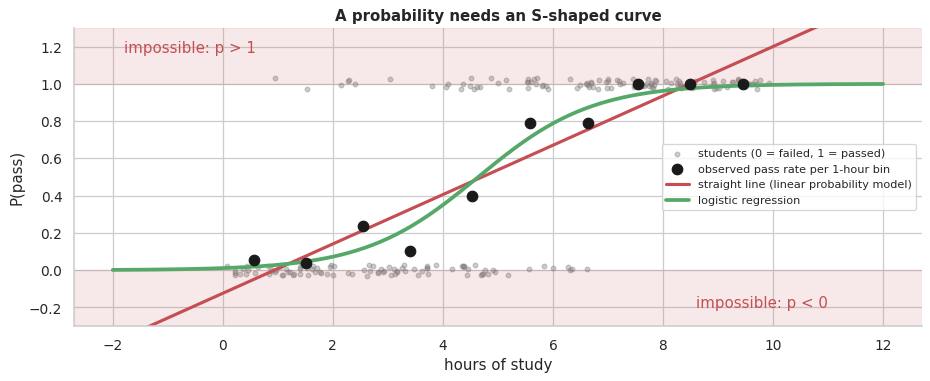

In [2]:
n = 200
study = pd.DataFrame({"hours": rng.uniform(0, 10, n)})
study["passed"] = (rng.random(n) < 1 / (1 + np.exp(-(-4 + .9 * study.hours)))).astype(int)
lpm = smf.ols("passed ~ hours", study).fit()
logit = smf.logit("passed ~ hours", study).fit(disp=0)

grid = pd.DataFrame({"hours": np.linspace(-2, 12, 300)})
binned = study.groupby(pd.cut(study.hours, np.arange(0, 11, 1)), observed=True).agg(hours=("hours", "mean"), share=("passed", "mean"))
fig, ax = plt.subplots(figsize=(10.5, 4.4))
ax.scatter(study.hours, study.passed + rng.uniform(-.03, .03, n), s=14, alpha=.4, color="grey", label="students (0 = failed, 1 = passed)")
ax.scatter(binned.hours, binned.share, s=70, color="k", zorder=3, label="observed pass rate per 1-hour bin")
ax.plot(grid.hours, lpm.predict(grid), color=C[3], lw=2.5, label="straight line (linear probability model)")
ax.plot(grid.hours, logit.predict(grid), color=C[2], lw=3, label="logistic regression")
ax.axhspan(1, 1.3, color=C[3], alpha=.12); ax.axhspan(-.3, 0, color=C[3], alpha=.12); ax.text(-1.8, 1.17, "impossible: p > 1", color=C[3]); ax.text(8.6, -.2, "impossible: p < 0", color=C[3])
ax.set(ylim=(-.3, 1.3), xlabel="hours of study", ylabel="P(pass)", title="A probability needs an S-shaped curve"); ax.legend(loc="center right", fontsize=9)
plt.tight_layout(); plt.show()

---
## 2. Probability, odds and log-odds

The fix: do not model $p$ directly, but a transformation of $p$ that can take any real value.

| Scale | Definition | Range | Example $p=0.8$ |
|---|---|---|---|
| **probability** | $p$ | 0 … 1 | 0.8 |
| **odds** | $\dfrac{p}{1-p}$ ("4 to 1") | 0 … ∞ | 4 |
| **log-odds (logit)** | $\ln\dfrac{p}{1-p}$ | −∞ … +∞ | 1.386 |

Logistic regression assumes that the **log-odds are linear** in the predictors. Inverting the logit gives the S-shaped **logistic (sigmoid) function**:

$$\ln\frac{p}{1-p}=\beta_0+\beta_1x \qquad\Longleftrightarrow\qquad p=\frac{1}{1+e^{-(\beta_0+\beta_1x)}}$$

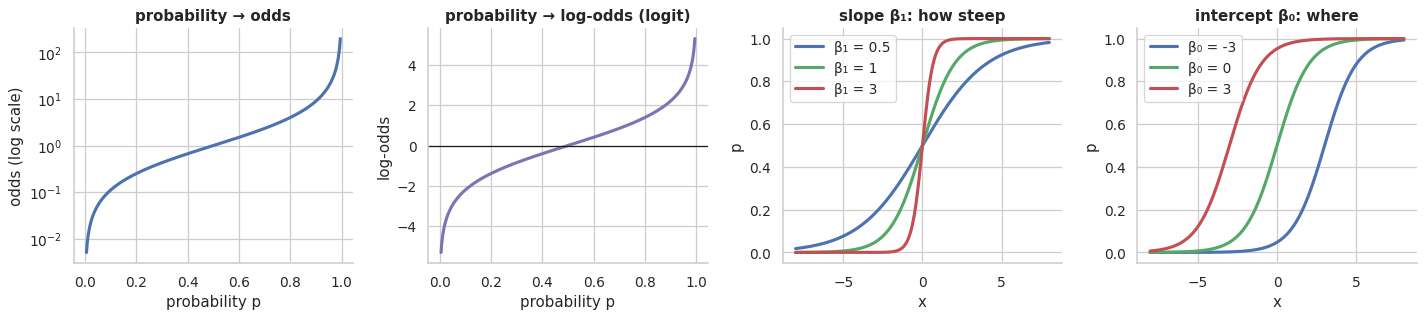

In [3]:
p = np.linspace(.005, .995, 400); x = np.linspace(-8, 8, 400); sigmoid = lambda z: 1 / (1 + np.exp(-z))
fig, axes = plt.subplots(1, 4, figsize=(16, 3.7))
axes[0].plot(p, p / (1 - p), color=C[0], lw=2.5); axes[0].set(yscale="log", xlabel="probability p", ylabel="odds (log scale)", title="probability → odds")
axes[1].plot(p, np.log(p / (1 - p)), color=C[4], lw=2.5); axes[1].axhline(0, color="k", lw=1); axes[1].set(xlabel="probability p", ylabel="log-odds", title="probability → log-odds (logit)")
for b1, col in zip([.5, 1, 3], [C[0], C[2], C[3]]): axes[2].plot(x, sigmoid(b1 * x), color=col, lw=2.5, label=f"β₁ = {b1}")
axes[2].set(xlabel="x", ylabel="p", title="slope β₁: how steep"); axes[2].legend()
for b0, col in zip([-3, 0, 3], [C[0], C[2], C[3]]): axes[3].plot(x, sigmoid(b0 + x), color=col, lw=2.5, label=f"β₀ = {b0}")
axes[3].set(xlabel="x", ylabel="p", title="intercept β₀: where"); axes[3].legend()
plt.tight_layout(); plt.show()

**Reading the figure.** The logit stretches the interval (0, 1) onto the whole real line: $p=0.5$ ↦ 0, $p=0.9$ ↦ +2.2, $p=0.99$ ↦ +4.6 — symmetric around 0. The slope $\beta_1$ controls how quickly the curve switches from 0 to 1; the curve crosses $p=0.5$ at $x=-\beta_0/\beta_1$.

---
## 3. The model and its estimation by maximum likelihood

Each observation is a Bernoulli trial with its own success probability $p_i$. There is no closed-form solution; we maximise the log-likelihood (Module 5) numerically:

$$\ell(\beta)=\sum_{i=1}^n\Big[y_i\ln p_i+(1-y_i)\ln(1-p_i)\Big],\qquad p_i=\frac{1}{1+e^{-(\beta_0+\beta_1x_i)}}$$

Every observation contributes the log of the probability the model assigned **to what actually happened** — a confident wrong prediction ($p_i=0.99$, $y_i=0$) is punished severely. ($-\ell/n$ is the *log-loss* or *cross-entropy* of machine learning.)

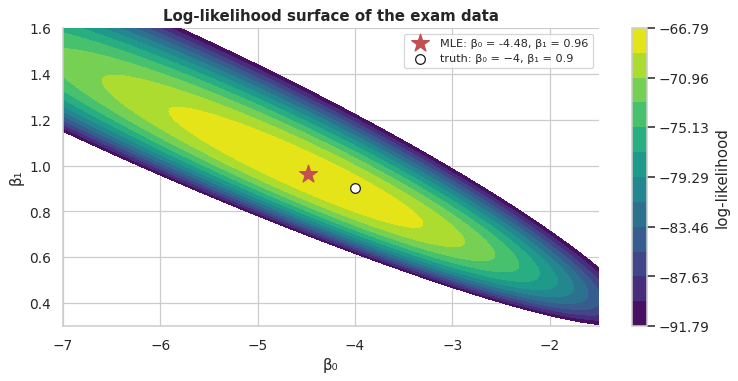

                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -4.4786      0.634     -7.061      0.000      -5.722      -3.235
hours          0.9649      0.127      7.572      0.000       0.715       1.215


In [4]:
B0, B1 = np.meshgrid(np.linspace(-7, -1.5, 140), np.linspace(.3, 1.6, 140))
eta = B0[..., None] + B1[..., None] * study.hours.values
loglik = (study.passed.values * eta - np.log1p(np.exp(eta))).sum(axis=-1)
fig, ax = plt.subplots(figsize=(8.5, 4.4))
cs = ax.contourf(B0, B1, loglik, levels=np.linspace(loglik.max() - 25, loglik.max(), 13), cmap="viridis"); plt.colorbar(cs, label="log-likelihood")
ax.scatter(*logit.params, marker="*", s=220, color=C[3], zorder=3, label=f"MLE: β₀ = {logit.params.iloc[0]:.2f}, β₁ = {logit.params.iloc[1]:.2f}")
ax.scatter(-4, .9, color="white", edgecolor="k", s=60, zorder=3, label="truth: β₀ = −4, β₁ = 0.9")
ax.set(xlabel="β₀", ylabel="β₁", title="Log-likelihood surface of the exam data"); ax.legend(loc="upper right", fontsize=9)
plt.tight_layout(); plt.show()
print(logit.summary().tables[1])

The output reads like a linear-regression table (coefficient, standard error, Wald $z$-test, confidence interval) — but all numbers live on the **log-odds scale**. The elongated, tilted likelihood ridge shows that $\beta_0$ and $\beta_1$ are strongly negatively correlated — another reason to centre predictors.

---
## 4. Interpreting the coefficients

* **Odds ratio:** $e^{\beta_1}$ is the factor by which the **odds** are multiplied for each additional unit of $x$ — the same factor everywhere on the curve. In the exam data the estimate is $e^{0.96}\approx 2.6$ (true value: $e^{0.9}\approx2.5$): every extra hour of study multiplies the odds of passing by about 2.6.
* **Probability scale:** the effect of one unit on the *probability* is **not constant** — it is largest in the middle of the curve and vanishes at the extremes. Rule of thumb: the maximum slope (at $p=0.5$) is $\beta_1/4$ ("divide-by-4 rule").
* **Best practice:** report odds ratios with CIs *and* translate the model into **predicted probabilities for concrete profiles**.

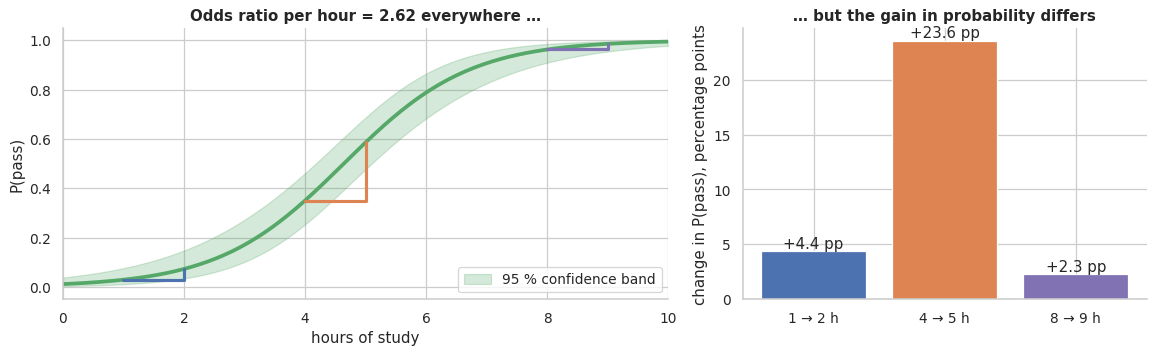

In [5]:
Xg = np.column_stack([np.ones(len(grid)), grid.hours]); eta_g = Xg @ logit.params.values
se = np.sqrt(np.einsum("ij,jk,ik->i", Xg, logit.cov_params().values, Xg))                   # standard error of the linear predictor
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4.1), gridspec_kw={"width_ratios": [1.5, 1]})
a1.plot(grid.hours, sigmoid(eta_g), color=C[2], lw=3); a1.fill_between(grid.hours, sigmoid(eta_g - 1.96 * se), sigmoid(eta_g + 1.96 * se), color=C[2], alpha=.25, label="95 % confidence band")
steps = [(1, 2), (4, 5), (8, 9)]; deltas = []
for (h0, h1), col in zip(steps, [C[0], C[1], C[4]]):
    p0, p1 = logit.predict(pd.DataFrame({"hours": [h0, h1]})); deltas.append(p1 - p0)
    a1.plot([h0, h1, h1], [p0, p0, p1], color=col, lw=2.5)
a1.set(xlim=(0, 10), xlabel="hours of study", ylabel="P(pass)", title=f"Odds ratio per hour = {np.exp(logit.params['hours']):.2f} everywhere …"); a1.legend(loc="lower right")
bars = a2.bar([f"{a} → {b} h" for a, b in steps], np.array(deltas) * 100, color=[C[0], C[1], C[4]]); a2.bar_label(bars, fmt="%+.1f pp")
a2.set(ylabel="change in P(pass), percentage points", title="… but the gain in probability differs")
plt.tight_layout(); plt.show()

---
## 5. From probabilities to decisions — thresholds and the confusion matrix

A logistic regression outputs a probability. To *act* (block the transaction, call the customer, order a biopsy) we need a **threshold**: predict "positive" if $\hat p\ge t$. Every threshold produces a **confusion matrix**:

| | predicted negative | predicted positive |
|---|---|---|
| **actually negative** | true negative (TN) | false positive (FP) |
| **actually positive** | false negative (FN) | true positive (TP) |

| Metric | Formula | Question it answers |
|---|---|---|
| **Sensitivity / recall / TPR** | TP / (TP + FN) | Of all real positives, how many did we catch? |
| **Specificity** (= 1 − FPR) | TN / (TN + FP) | Of all real negatives, how many did we leave alone? |
| **Precision / PPV** | TP / (TP + FP) | Of all alarms, how many were real? *(depends on prevalence — Module 2!)* |
| **Accuracy** | (TP + TN) / n | Share of correct decisions — **misleading for rare events** |

The default threshold 0.5 is almost never the right one when classes are imbalanced or errors have different costs. **Simulated example:** 10 % of cases are positive.

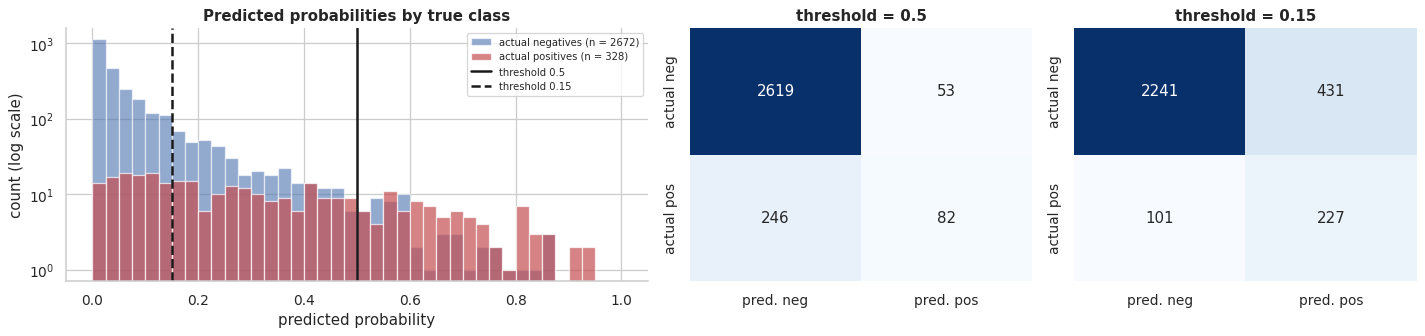

,sensitivity,specificity,precision,accuracy
threshold 0.5,0.250,0.980,0.607,0.900
threshold 0.15,0.692,0.839,0.345,0.823
always predict 'negative',0.000,1.000,NaN,0.891


In [6]:
n = 6000
X = rng.normal(0, 1, (n, 2)); y = (rng.random(n) < sigmoid(-3.1 + 1.5 * X[:, 0] + 1.0 * X[:, 1])).astype(int)
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=.5, random_state=0, stratify=y)
clf = LogisticRegression().fit(X_tr, y_tr); p_hat = clf.predict_proba(X_te)[:, 1]

fig, axes = plt.subplots(1, 3, figsize=(16, 3.9), gridspec_kw={"width_ratios": [1.7, 1, 1]})
bins = np.linspace(0, 1, 41)
axes[0].hist(p_hat[y_te == 0], bins=bins, color=C[0], alpha=.6, label=f"actual negatives (n = {(y_te == 0).sum()})"); axes[0].hist(p_hat[y_te == 1], bins=bins, color=C[3], alpha=.7, label=f"actual positives (n = {(y_te == 1).sum()})")
for t, ls in [(.5, "-"), (.15, "--")]: axes[0].axvline(t, color="k", ls=ls, lw=2, label=f"threshold {t}")
axes[0].set(yscale="log", xlabel="predicted probability", ylabel="count (log scale)", title="Predicted probabilities by true class"); axes[0].legend(fontsize=8)
rows = {}
for ax, t in zip(axes[1:], [.5, .15]):
    cm = confusion_matrix(y_te, p_hat >= t); tn, fp, fn, tp = cm.ravel()
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax, xticklabels=["pred. neg", "pred. pos"], yticklabels=["actual neg", "actual pos"]); ax.set_title(f"threshold = {t}")
    rows[f"threshold {t}"] = {"sensitivity": tp / (tp + fn), "specificity": tn / (tn + fp), "precision": tp / (tp + fp), "accuracy": (tp + tn) / cm.sum()}
plt.tight_layout(); plt.show()
rows["always predict 'negative'"] = {"sensitivity": 0, "specificity": 1, "precision": np.nan, "accuracy": (y_te == 0).mean()}
pd.DataFrame(rows).T.round(3)

**Reading the output.** With threshold 0.5 the model looks accurate — but so does the useless rule "always predict negative" (accuracy ≈ 89 %), and the model misses three quarters of the real positives. Lowering the threshold to 0.15 catches far more positives (sensitivity ↑) at the price of more false alarms (precision ↓, specificity ↓). Neither threshold is "correct" — the choice depends on the **costs** of the two error types (Exercise 11.2).

---
## 6. ROC curve, AUC and the precision–recall curve

Instead of picking one threshold, sweep through all of them:

* The **ROC curve** plots sensitivity (TPR) against the false-positive rate (1 − specificity). The diagonal is a coin flip; the top-left corner is perfection.
* The **AUC** (area under the ROC curve) has a beautiful interpretation: it is the probability that a randomly chosen positive receives a higher score than a randomly chosen negative — exactly the *probability of superiority* of the Mann–Whitney test (Module 7). It measures **ranking quality**, independent of threshold and prevalence.
* For **rare positives** the **precision–recall curve** is more informative: a tiny false-positive *rate* applied to a huge number of negatives can still swamp the true positives.

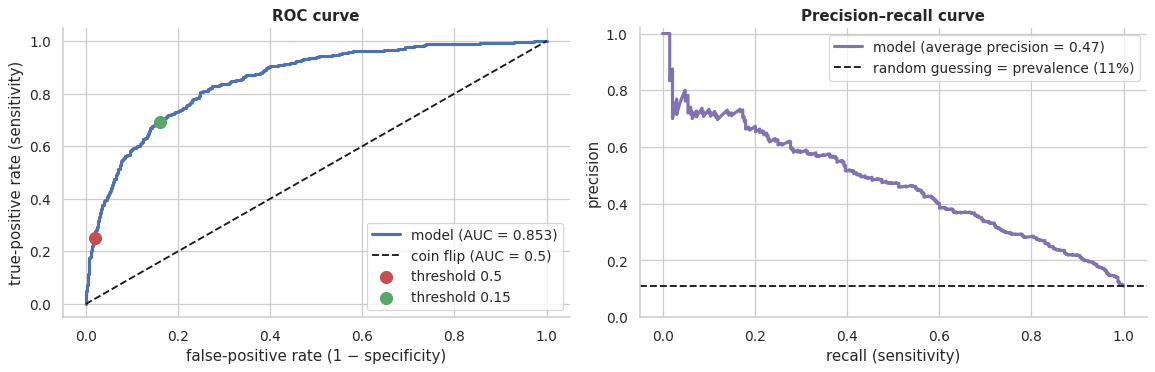

AUC = 0.8529   =   Mann–Whitney U / (n₁·n₀) = 0.8529


In [7]:
fpr, tpr, thr = roc_curve(y_te, p_hat); prec, rec, thr_pr = precision_recall_curve(y_te, p_hat)
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4.3))
a1.plot(fpr, tpr, color=C[0], lw=2.5, label=f"model (AUC = {roc_auc_score(y_te, p_hat):.3f})"); a1.plot([0, 1], [0, 1], "k--", label="coin flip (AUC = 0.5)")
for t, col in [(.5, C[3]), (.15, C[2])]:
    i = np.abs(thr - t).argmin(); a1.scatter(fpr[i], tpr[i], s=90, color=col, zorder=3, label=f"threshold {t}")
a1.set(xlabel="false-positive rate (1 − specificity)", ylabel="true-positive rate (sensitivity)", title="ROC curve"); a1.legend(loc="lower right")
a2.plot(rec, prec, color=C[4], lw=2.5, label=f"model (average precision = {average_precision_score(y_te, p_hat):.2f})"); a2.axhline(y_te.mean(), color="k", ls="--", label=f"random guessing = prevalence ({y_te.mean():.0%})")
a2.set(xlabel="recall (sensitivity)", ylabel="precision", title="Precision–recall curve", ylim=(0, 1.02)); a2.legend()
plt.tight_layout(); plt.show()
u = stats.mannwhitneyu(p_hat[y_te == 1], p_hat[y_te == 0]).statistic
print(f"AUC = {roc_auc_score(y_te, p_hat):.4f}   =   Mann–Whitney U / (n₁·n₀) = {u / ((y_te == 1).sum() * (y_te == 0).sum()):.4f}")

---
## 7. Calibration — can you take the probabilities at face value?

A model can rank perfectly (high AUC) and still output misleading probabilities. A model is **calibrated** if, among all cases where it says "30 %", about 30 % are really positive. Calibration matters whenever the probability itself is used: expected-cost decisions, pricing, risk communication, thresholds derived from costs.

Check it with a **reliability diagram** (bin the predictions, compare mean prediction with the observed frequency) and summarise with the **Brier score** $\frac1n\sum(\hat p_i-y_i)^2$ (lower is better). Logistic regression fitted by maximum likelihood is calibrated on its training population by construction; many machine-learning models (boosted trees, naive Bayes, models trained on re-balanced data) are not.

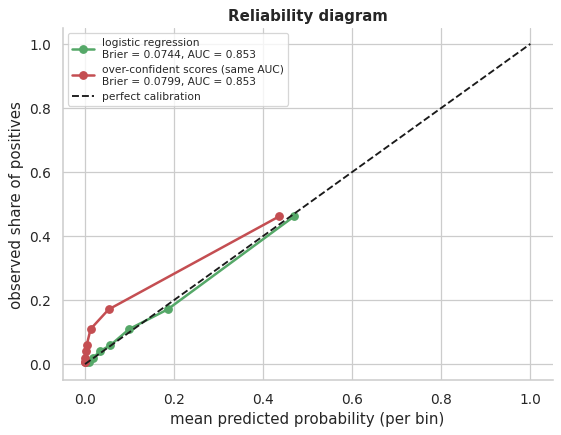

In [8]:
p_over = p_hat ** 2 / (p_hat ** 2 + (1 - p_hat) ** 2)               # a distorted, over-confident version of the same scores: identical ranking!
fig, ax = plt.subplots(figsize=(6.4, 5))
for probs, name, col in [(p_hat, "logistic regression", C[2]), (p_over, "over-confident scores (same AUC)", C[3])]:
    frac_pos, mean_pred = calibration_curve(y_te, probs, n_bins=8, strategy="quantile")
    ax.plot(mean_pred, frac_pos, "o-", color=col, lw=2, label=f"{name}\nBrier = {brier_score_loss(y_te, probs):.4f}, AUC = {roc_auc_score(y_te, probs):.3f}")
ax.plot([0, 1], [0, 1], "k--", label="perfect calibration"); ax.set(xlabel="mean predicted probability (per bin)", ylabel="observed share of positives", title="Reliability diagram"); ax.legend(fontsize=8.5)
plt.tight_layout(); plt.show()

---
## 8. Poisson regression — modelling counts

Counts (0, 1, 2, …) are non-negative, skewed, and their variance grows with their mean — three violations of the linear-model assumptions. **Poisson regression** assumes $y_i\sim\text{Poisson}(\mu_i)$ with a **log link**:

$$\ln\mu_i=\beta_0+\beta_1x_i \qquad\Longleftrightarrow\qquad \mu_i=e^{\beta_0}\,(e^{\beta_1})^{x_i}$$

Effects are **multiplicative**: $e^{\beta_1}$ is a **rate ratio** — the factor by which the expected count changes per unit of $x$.

**Exposure.** Counts usually arise over different amounts of *exposure* (policy-years, km driven, population, hours observed). We model the **rate** $\mu_i/t_i$ by adding $\ln t_i$ as an **offset** (a predictor whose coefficient is fixed at 1): $\;\ln\mu_i=\ln t_i+\beta_0+\beta_1x_i$.

**Overdispersion.** The Poisson model *forces* variance = mean. Real counts are usually more variable (unobserved heterogeneity, clustering). The coefficients are still fine, but the **standard errors are too small**. Diagnose with the dispersion statistic Pearson $\chi^2/\text{df}$ (should be ≈ 1); remedies: **quasi-Poisson** (scale the SEs) or the **negative-binomial** model (variance $=\mu+\alpha\mu^2$).

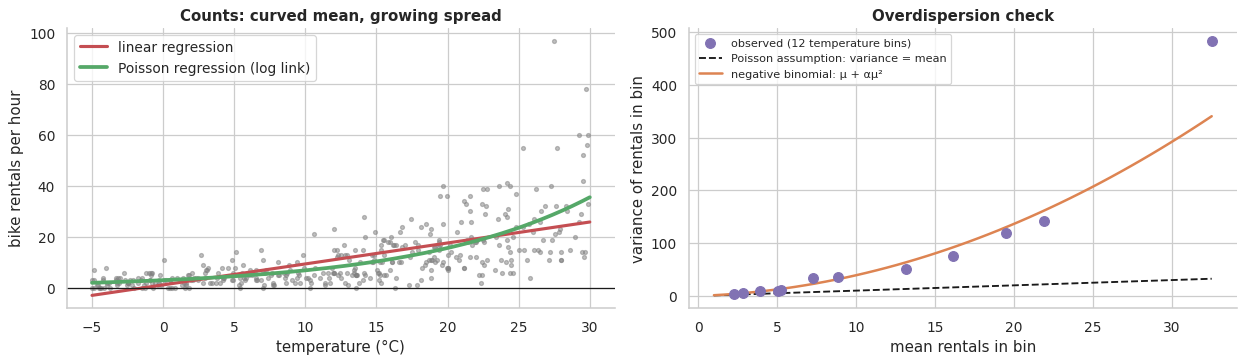

rate ratio per °C: exp(0.0820) = 1.085  ->  +8.5% rentals per additional degree
dispersion statistic (Pearson chi² / df) = 4.39   (≈ 1 if the Poisson model were adequate)
                            Poisson  quasi-Poisson  negative binomial
SE of the temp coefficient  0.00181        0.00379            0.00348


In [9]:
n = 400
bikes = pd.DataFrame({"temp": rng.uniform(-5, 30, n)})
mu = np.exp(1.0 + .085 * bikes.temp)
bikes["rentals"] = rng.poisson(mu * rng.gamma(4, 1 / 4, n))                      # gamma-mixed Poisson = negative binomial: extra day-to-day variation
lin = smf.ols("rentals ~ temp", bikes).fit()
pois = smf.glm("rentals ~ temp", data=bikes, family=sm.families.Poisson()).fit()
quasi = smf.glm("rentals ~ temp", data=bikes, family=sm.families.Poisson()).fit(scale="X2")             # quasi-Poisson: same coefficients, honest SEs
negbin = smf.negativebinomial("rentals ~ temp", data=bikes).fit(disp=0)

grid = pd.DataFrame({"temp": np.linspace(-5, 30, 200)})
fig, (a1, a2) = plt.subplots(1, 2, figsize=(14, 4.2))
a1.scatter(bikes.temp, bikes.rentals, s=10, alpha=.5, color="grey"); a1.plot(grid.temp, lin.predict(grid), color=C[3], lw=2.5, label="linear regression"); a1.plot(grid.temp, pois.predict(grid), color=C[2], lw=3, label="Poisson regression (log link)")
a1.axhline(0, color="k", lw=1); a1.set(xlabel="temperature (°C)", ylabel="bike rentals per hour", title="Counts: curved mean, growing spread"); a1.legend()
b = bikes.assign(bin=pd.cut(bikes.temp, 12)).groupby("bin", observed=True).rentals.agg(["mean", "var"])
a2.scatter(b["mean"], b["var"], s=60, color=C[4], zorder=3, label="observed (12 temperature bins)"); mm = np.linspace(1, b["mean"].max(), 50)
a2.plot(mm, mm, "k--", label="Poisson assumption: variance = mean"); a2.plot(mm, mm + negbin.params["alpha"] * mm ** 2, color=C[1], lw=2, label="negative binomial: μ + αμ²")
a2.set(xlabel="mean rentals in bin", ylabel="variance of rentals in bin", title="Overdispersion check"); a2.legend(fontsize=9)
plt.tight_layout(); plt.show()
print(f"rate ratio per °C: exp({pois.params['temp']:.4f}) = {np.exp(pois.params['temp']):.3f}  ->  +{np.expm1(pois.params['temp']):.1%} rentals per additional degree")
print(f"dispersion statistic (Pearson chi² / df) = {pois.pearson_chi2 / pois.df_resid:.2f}   (≈ 1 if the Poisson model were adequate)")
print(pd.DataFrame({"Poisson": pois.bse, "quasi-Poisson": quasi.bse, "negative binomial": negbin.bse.drop("alpha")}).loc[["temp"]].rename(index={"temp": "SE of the temp coefficient"}).round(5))

**Reading the output.** The straight line predicts negative rentals on cold days and misses the curvature; the Poisson model captures both. The variance, however, grows much faster than the mean: the dispersion statistic is far above 1, and the naive Poisson standard error is too small by a factor of about $\sqrt{\text{dispersion}}$. Quasi-Poisson and negative-binomial models give similar, honest standard errors.

---
## 9. The GLM family — one recipe, many models

Every GLM has three ingredients: a **distribution** for the outcome, a **linear predictor** $\eta=\mathbf x^\top\boldsymbol\beta$, and a **link function** $g$ connecting the mean to the linear predictor, $g(\mu)=\eta$. All are fitted by maximum likelihood.

| Outcome | Distribution | Usual link | Model | $e^\beta$ is a … | statsmodels |
|---|---|---|---|---|---|
| numeric, symmetric | Normal | identity | linear regression | — (additive effect $\beta$) | `smf.ols` |
| binary | Bernoulli / binomial | logit | logistic regression | odds ratio | `smf.logit`, `smf.glm(..., family=Binomial())` |
| count | Poisson | log | Poisson regression | rate ratio | `smf.glm(..., family=Poisson())` |
| overdispersed count | negative binomial | log | NB regression | rate ratio | `smf.negativebinomial` |
| positive, right-skewed (costs, durations) | Gamma | log | Gamma regression | multiplicative effect on the mean | `smf.glm(..., family=Gamma(link=Log()))` |

Model comparison works as in Module 10, with the **deviance** ($-2\times$ log-likelihood, relative to a perfect fit) taking the role of the residual sum of squares: nested models are compared with likelihood-ratio tests, non-nested ones with AIC/BIC or — for prediction — cross-validation.

---
## 10. Exercises — real-world use cases
Each exercise is self-contained. Run the data cell, then work in the empty cell below it.

### ✍️ Exercise 11.1 — *Logistic regression & odds ratios*: Who cancels their contract? (Telecom churn)

A telecom provider wants to understand which customers churn. For 3,000 customers you know tenure (months), monthly fee (€), contract type, number of support calls in the last quarter, and whether they churned.

**Tasks**
1. Compute the churn rate overall and by contract type.
2. Fit a logistic regression with all four predictors. Tabulate **odds ratios with 95 % CIs** and draw them as a forest plot (log scale).
3. Interpret: the odds ratio per support call; per **12 months** of tenure; of a two-year vs. a monthly contract.
4. Predict the churn probability for (a) a new monthly customer (tenure 3, fee €70, 3 support calls) and (b) a loyal two-year customer (tenure 48, fee €50, no calls).
5. Management concludes: "Move everybody to two-year contracts and churn will drop by 85 %." Comment.

In [10]:
g = np.random.default_rng(1101)
n = 3000
tel = pd.DataFrame({"tenure": g.gamma(2, 12, n).clip(1, 72).round(0), "fee": g.normal(55, 15, n).clip(20, 110).round(0),
                    "contract": pd.Categorical(g.choice(["monthly", "one-year", "two-year"], n, p=[.55, .25, .20]), categories=["monthly", "one-year", "two-year"]),
                    "support_calls": g.poisson(1.2, n)})
eta = -.4 - .045 * tel.tenure + .02 * (tel.fee - 55) + .45 * tel.support_calls + tel.contract.map({"monthly": 0, "one-year": -1.0, "two-year": -1.9}).astype(float)
tel["churn"] = (g.random(n) < 1 / (1 + np.exp(-eta))).astype(int)
tel.head()

,tenure,fee,contract,support_calls,churn
0,23.0,66.0,monthly,2,1
1,8.0,70.0,monthly,0,0
2,55.0,51.0,monthly,0,0
3,9.0,50.0,monthly,0,0
4,23.0,49.0,monthly,3,0


In [11]:
# ✍️ Your turn — write your solution here


> 💡 **Stuck, or want to compare?** The fully worked solution (with plots and interpretation) is in `solutions/11_logistic_regression_glm_solutions.ipynb`.

### ✍️ Exercise 11.2 — *Thresholds & costs*: Whom should the bank lend to? (Credit scoring)

A bank scores loan applicants with a logistic regression. Approving a customer who later **defaults** costs on average **€5,000**; rejecting a customer who **would have repaid** loses **€600** of profit.

**Tasks**
1. Split the data (70 % training / 30 % test), fit the model on the training part and report the test AUC.
2. Show the confusion matrix at threshold 0.5. What share of the defaulters is caught?
3. For thresholds from 0.01 to 0.99, compute the **average cost per applicant** on the test set. Plot the cost curve and find the optimal threshold.
4. Compare with the theoretical optimum for a calibrated model, $t^*=\dfrac{c_{FP}}{c_{FP}+c_{FN}}$. How much money does the optimal threshold save per 10,000 applicants compared with 0.5 — and compared with approving everybody?

In [12]:
g = np.random.default_rng(1102)
n = 6000
loans = pd.DataFrame({"log_income": g.normal(10.6, .4, n).round(3), "debt_ratio": g.beta(2, 5, n).round(3), "late_payments": g.poisson(.6, n)})
eta = -2.2 - .9 * (loans.log_income - 10.6) + 3.2 * (loans.debt_ratio - .28) + .55 * loans.late_payments
loans["default"] = (g.random(n) < 1 / (1 + np.exp(-eta))).astype(int)
c_fn, c_fp = 5000, 600
print(f"default rate: {loans.default.mean():.1%}"); loans.head()

default rate: 17.0%


,log_income,debt_ratio,late_payments,default
0,10.840,0.274,1,0
1,11.055,0.155,0,0
2,10.022,0.178,0,1
3,10.307,0.315,0,0
4,10.172,0.437,0,1


In [13]:
# ✍️ Your turn — write your solution here


> 💡 **Stuck, or want to compare?** The fully worked solution (with plots and interpretation) is in `solutions/11_logistic_regression_glm_solutions.ipynb`.

### ✍️ Exercise 11.3 — *ROC, cross-validation & sensitivity*: A diagnostic model for breast cancer (Medicine, real data)

The Wisconsin breast-cancer data contain 30 measurements of cell nuclei from 569 biopsies, with the diagnosis (malignant / benign).

**Tasks**
1. Split the data (stratified, 30 % test). Build a pipeline *standardise → logistic regression* and estimate its AUC by 5-fold cross-validation **on the training set**.
2. Evaluate on the test set: AUC and confusion matrix at threshold 0.5.
3. In cancer diagnostics a missed tumour is far worse than an unnecessary follow-up. Report sensitivity and specificity at thresholds 0.5 and 0.1.
4. Which five features have the largest standardised coefficients? Why should you be careful when interpreting them? (Hint: Module 10.)

In [14]:
bc = load_breast_cancer(as_frame=True)
X, y = bc.data, (bc.target == 0).astype(int)                    # sklearn codes malignant as 0 -> we recode: 1 = malignant
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.3, random_state=0, stratify=y)
print(X.shape, f"share malignant: {y.mean():.1%}")

(569, 30) share malignant: 37.3%


In [15]:
# ✍️ Your turn — write your solution here


> 💡 **Stuck, or want to compare?** The fully worked solution (with plots and interpretation) is in `solutions/11_logistic_regression_glm_solutions.ipynb`.

### ✍️ Exercise 11.4 — *Poisson regression with exposure*: Pricing motor insurance (Actuarial science)

An insurer analyses the **claim frequency** of 8,000 motor policies. Policies were in force for different fractions of the year (`exposure`). Predictors: driver's age group and engine power.

**Tasks**
1. Compute the crude claim frequency (claims per policy-year) by age group — once correctly (total claims / total exposure) and once naively (mean number of claims per policy). What goes wrong with the naive version?
2. Fit a Poisson GLM with `offset = log(exposure)`. Tabulate the **rate ratios** with 95 % CIs (reference: age 26–40, low power).
3. What is the expected number of claims per year for an 18–25-year-old with a high-powered car, and for a 41–65-year-old with a low-powered car?
4. Check the dispersion statistic. Then refit **without** the offset and compare the rate ratio of the young drivers. Explain.

In [16]:
g = np.random.default_rng(1104)
n = 8000
mot = pd.DataFrame({"age_group": pd.Categorical(g.choice(["26-40", "18-25", "41-65", "66+"], n, p=[.35, .12, .40, .13]), categories=["26-40", "18-25", "41-65", "66+"]),
                    "power": pd.Categorical(g.choice(["low", "medium", "high"], n, p=[.4, .4, .2]), categories=["low", "medium", "high"])})
mot["exposure"] = np.where(mot.age_group == "18-25", g.uniform(.1, .6, n), g.uniform(.3, 1, n)).round(2)          # young drivers: mostly new, short-running policies
rate = .08 * mot.age_group.map({"26-40": 1.0, "18-25": 2.2, "41-65": .8, "66+": 1.3}).astype(float) * mot.power.map({"low": 1.0, "medium": 1.25, "high": 1.7}).astype(float)
mot["claims"] = g.poisson(rate * mot.exposure)
mot.head()

,age_group,power,exposure,claims
0,26-40,medium,0.79,0
1,26-40,low,0.58,0
2,41-65,high,0.36,0
3,41-65,high,0.69,0
4,41-65,low,0.64,0


In [17]:
# ✍️ Your turn — write your solution here


> 💡 **Stuck, or want to compare?** The fully worked solution (with plots and interpretation) is in `solutions/11_logistic_regression_glm_solutions.ipynb`.

---
## 11. 🔑 Key takeaways

* For a binary outcome model the **log-odds** linearly: $\ln\frac{p}{1-p}=\mathbf x^\top\boldsymbol\beta$. Fitted by maximum likelihood (= minimising log-loss).
* $e^{\beta}$ is an **odds ratio** — constant along the curve, whereas the effect on the *probability* is largest near $p=0.5$. Always translate into predicted probabilities for concrete profiles; odds ratios are not risk ratios.
* A model gives probabilities; a **threshold** turns them into decisions and should come from **costs**, not from the default 0.5. Accuracy is misleading for rare events.
* **ROC/AUC** measure ranking (AUC = probability that a positive outranks a negative); **precision–recall** is more telling for rare positives; **calibration** tells you whether "30 %" means 30 %.
* **Poisson regression** (log link) gives **rate ratios**; use an **offset** for unequal exposure and check **overdispersion** (quasi-Poisson or negative binomial).
* All of these are **GLMs**: distribution + linear predictor + link. Interactions, dummies, confounding, regularisation — everything from Module 10 carries over.

### Cheat sheet
| Task | Code |
|---|---|
| logistic regression | `m = smf.logit("y ~ x1 + x2 + group", df).fit()` |
| odds ratios with CI | `np.exp(m.params)`, `np.exp(m.conf_int())` |
| predicted probabilities | `m.predict(new_df)` |
| scikit-learn pipeline | `make_pipeline(StandardScaler(), LogisticRegression(C=1.0)).fit(X, y).predict_proba(X)[:, 1]` |
| confusion matrix, AUC | `confusion_matrix(y, p >= t)`, `roc_auc_score(y, p)`, `roc_curve(y, p)` |
| PR curve, calibration, Brier | `precision_recall_curve(y, p)`, `calibration_curve(y, p, n_bins=10)`, `brier_score_loss(y, p)` |
| Poisson GLM with exposure | `smf.glm("y ~ x", df, family=sm.families.Poisson(), offset=np.log(df.exposure)).fit()` |
| overdispersion | `m.pearson_chi2 / m.df_resid`; `.fit(scale="X2")`; `smf.negativebinomial("y ~ x", df).fit()` |

**Next:** Module 12 — Bayesian statistics: turning likelihoods into probability statements about parameters.